# Kapacita vs. výstup závodu: dvourozměrná analýza portfolia pomocí PROC SGPLOT

## Shrnutí pro vedení

Výrobní portfolio v diskrétní výrobě má dvě čísla, která jsou důležitá u každé produktové linky současně: **kolik strojní kapacity spotřebuje** a **kolik dobrého výstupu skutečně dodá**. Jednorozměrný sloupcový graf dokáže zobrazit jen jedno z nich. Tento notebook vizualizuje obě veličiny současně pomocí `PROC SGPLOT` s **bublinovým grafem** jako hlavním pohledem — každá linka je umístěna podle kapacity (x) a výstupu (y), s velikostí bubliny kódující její produktivitu (kusy na strojhodinu). Linky, které leží vpravo dole (velká kapacita, malý výstup), jsou kapacitní propady; linky vlevo nahoře s velkou bublinou jsou vysoce výnosné. Seskupený sloupcový pohled pak rozkládá výstup podle závodu a žebříček produktivity potvrzuje rozdíl.

Na základě skutečně provedeného výstupu (osm produktových linek napříč třemi závody, 100 směnových běhů agregovaných do 24 buněk linka-závod) analýza zjišťuje, že **Odlévání** je nejvýraznějším kapacitním propadem portfolia (14,3 dobrých kusů na strojhodinu — spotřebuje 10,1 % celkové kapacity, ale dodává pouze 3,2 % dobrých kusů), zatímco **Balení** je špičkovou vysoce výnosnou linkou (119,2 kusů za hodinu — 9,1 % kapacity vrací 23,8 % výstupu). Napříč závody běží **Stuttgart** nejžhavěji s 49,9 kusy/hod a **Monterrey** nejchladněji s 41,6.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Syntetické směnové výrobní záznamy napříč 8 produktovými linkami, 3 závody a 3 směnami — plánované strojhodiny, hodiny provozu, prostoje, hrubé/zmetkové/dobré kusy (omezeno na 100 pozorování v nelicencovaném režimu) | 100 |
| WORK.LINE_CAPACITY | Agregovaný souhrn za produktovou linku a závod: celkové kapacitní hodiny (x), vyrobené dobré kusy (y) a procento výtěžnosti přijatých kusů | 24 |

*Všechna data jsou syntetická a generovaná přímo v notebooku s pevným seedem — žádné externí soubory, žádná síť.*

# Analýza kapacity vs. výstupu závodu

**Doména:** Diskrétní výroba — provoz / průmyslové inženýrství

**Procedura:** `PROC SGPLOT` (ODS Statistical Graphics)

Konvenční sloupcový graf zobrazuje jednu odezvu na kategorii. Pro porovnání výrobního portfolia ve **dvou** číselných dimenzích současně — *kolik kapacity každá produktová linka spotřebuje* versus *kolik výstupu skutečně dodá* — potřebujeme graf, který umístí obě veličiny na stejné plátno. `PROC SGPLOT`'s příkaz `BUBBLE` dělá přesně to: umístí každou linku podle kapacity (x) a dobrých kusů (y) a nechá třetí míru, míru produktivity, řídit velikost bubliny. Linka, která leží daleko vpravo, ale nízko, je kapacitní propad; linka, která leží vysoko a vlevo s tlustou bublinou, je vysoce výnosná linka, kterou stojí za to chránit. Tento notebook sestavuje realistickou syntetickou výrobní datovou sadu a řídí SGPLOT přes bublinový graf, sloupcový graf seskupený podle závodu, detail jednoho závodu a vedle sebe postavené seskupené srovnání závodů.

> **Poznámka k PROC GAREABAR.** Klasický způsob SAS/GRAPH pro kódování dvou dimenzí na *sloupec* je `PROC GAREABAR` (graf typu area-bar pouze pro ActiveX, kde šířka sloupce kóduje jednu proměnnou a výška druhou). GAREABAR **není v této sestavě Jenner zatím implementován** — mezera je sledována bankovaným testem `tests/400996_nb_gareabar_unimplemented`. Tento notebook dosahuje stejného analytického cíle pomocí plně podporovaného `PROC SGPLOT`, jehož bublinový a seskupený sloupcový pohled zprostředkovávají identický příběh kapacity vs. výstupu.

## 1. Generování syntetických výrobních dat

Simulujeme šest týdnů směnových výrobních záznamů pro síť diskrétní výroby se třemi závody. Každá produktová linka má základní dobu cyklu a míru zmetkovitosti; výstup je řízen plánovanými strojhodinami, efektivitou specifickou pro danou linku a náhodnými prostoji. `call streaminit` fixuje seed, takže notebook je plně reprodukovatelný — žádné externí soubory, žádná síť.

In [1]:
/* --------------------------------------------------------
   Syntetické směnové výrobní záznamy
   8 produktových linek x 3 závody x 3 směny x ~10 dní
   sirka baru  = planovane strojhodiny (kapacita)
   odezva      = vyrobene dobre kusy  (vystup)
   -------------------------------------------------------- */
data work.production_runs;
    CALL streaminit(20260531);
    DÉLKA product_line $24 plant $12 shift $16;

    /* nominalni kusy vyrobene za strojhodinu, podle linky */
    POLE line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* zakladni podil zmetku podle linky */
    POLE line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    POLE plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* multiplikator efektivity zavodu */
    POLE plant_eff[3] _temporary_ (1.00 0.92 1.08);
    POLE shift_eff[3] _temporary_ (1.00 0.95 0.88);

    OPAKUJ day = 1 TO 10;
        OPAKUJ li = 1 TO 8;
            OPAKUJ pi = 1 TO 3;
                OPAKUJ si = 1 TO 3;
                    /* nazev produktove linky (primo, ne pole -
                       vyhyba se zname chybe enginu s _temporary_
                       polem znaku s nediakritickymi retezci) */
                    KDYŽ      li = 1 PAK product_line = "Lisování";
                    JINAK KDYŽ li = 2 PAK product_line = "Svařování";
                    JINAK KDYŽ li = 3 PAK product_line = "Obrábění";
                    JINAK KDYŽ li = 4 PAK product_line = "Odlévání";
                    JINAK KDYŽ li = 5 PAK product_line = "Vstřikování";
                    JINAK KDYŽ li = 6 PAK product_line = "Montáž";
                    JINAK KDYŽ li = 7 PAK product_line = "Dokončování";
                    JINAK                product_line = "Balení";

                    plant = plant_names[pi];

                    KDYŽ      si = 1 PAK shift = "Denní";
                    JINAK KDYŽ si = 2 PAK shift = "Odpolední";
                    JINAK                shift = "Noční";

                    /* planovane strojhodiny pro smenu */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* neplanovany prostoj snizuje kapacitu */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* efektivni miru vystupu se sumem */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    VÝSTUP;
                KONEC;
            KONEC;
        KONEC;
    KONEC;
    PONECHAT run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    FORMÁT run_date date9.;
SPUSTIT;

PROCEDURA TISK data=work.production_runs(obs=8) noobs ŠTÍTEK;
    ŠTÍTEK run_date="Datum směny" product_line="Produktová linka" plant="Závod"
          shift="Směna" sched_hours="Plánované hodiny" run_hours="Odpracované hodiny"
          downtime_hours="Prostoje (hod.)" gross_units="Hrubé kusy"
          scrap_units="Zmetkové kusy" good_units="Dobré kusy";
    NÁZEV 'Ukázka syntetických směnových výrobních záznamů';
SPUSTIT;
NÁZEV;

                                    Ukázka syntetických směnových výrobních záznamů                                     

 Datum směny   Produktová linka      Závod       Směna    Plánované hodiny   Odpracované hodiny  Prostoje (hod.)   Hrubé kusy   Zmetkové kusy   Dobré kusy
   05JAN2026  Lisování           Detroit    Denní                      7.8                  6.7              1.1          306              14          292
   05JAN2026  Lisování           Detroit    Odpolední                  6.8                  6.5              0.3          259              12          247
   05JAN2026  Lisování           Detroit    Noční                        8                  7.6              0.4          269              11          258
   05JAN2026  Lisování           Monterrey  Denní                      7.9                  6.8              1.1          283              12          271
   05JAN2026  Lisování           Monterrey  Odpolední                  7.5                  6.9        


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.21 seconds
  cpu   0.21 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Agregace na úroveň linky a závodu

Grafy porovnávají jeden bod na kategorii, takže agregujeme směnové detaily na souhrn za produktovou linku a závod. `total_capacity` (součet plánovaných strojhodin) se stává dimenzí **x**, `good_units` (součet přijatého výstupu) dimenzí **y** a `units_per_hr` (dobré kusy ÷ kapacitní hodiny) mírou produktivity, která bude určovat velikost bublin. Ponecháváme `plant`, aby později sloužil jako seskupovací proměnná. Sestavujeme také souhrn na úrovni linky (napříč závody) pro bublinový graf portfolia.

In [2]:
/* --------------------------------------------------------
   Agregace na product_line x plant
   total_capacity -> x (kapacitni hodiny)
   good_units     -> y (vystup)
   units_per_hr   -> velikost bubliny (produktivita)
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.production_runs NOPRINT NWAY;
    TŘÍDA product_line plant;
    PROMĚNNÁ sched_hours good_units scrap_units;
    VÝSTUP out=work.line_capacity(ODSTRANIT=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
SPUSTIT;

data work.line_capacity;
    NASTAVIT work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    FORMÁT units_per_hr 6.1 yield_pct 5.1;
SPUSTIT;

PROCEDURA ŘADIT data=work.line_capacity;
    PODLE product_line plant;
SPUSTIT;

/* Souhrn na úrovni linky (napříč všemi třemi závody) pro pohled portfolia */
PROCEDURA PRŮMĚRY data=work.line_capacity NOPRINT NWAY;
    TŘÍDA product_line;
    PROMĚNNÁ total_capacity good_units;
    VÝSTUP out=work.line_total(ODSTRANIT=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
SPUSTIT;

data work.line_total;
    NASTAVIT work.line_total;
    units_per_hr = good_units / total_capacity;
    FORMÁT units_per_hr 6.1;
SPUSTIT;

PROCEDURA ŘADIT data=work.line_total;
    PODLE units_per_hr;
SPUSTIT;

PROCEDURA TISK data=work.line_total noobs ŠTÍTEK;
    PROMĚNNÁ product_line total_capacity good_units units_per_hr;
    ŠTÍTEK product_line="Produktová linka" total_capacity="Celková kapacita (hod.)"
          good_units="Dobré kusy" units_per_hr="Kusy za hodinu";
    NÁZEV 'Linky portfolia seřazené podle produktivity (dobré kusy na strojhodinu)';
SPUSTIT;
NÁZEV;

                        Linky portfolia seřazené podle produktivity (dobré kusy na strojhodinu)                         

 Produktová linka   Celková kapacita (hod.)   Dobré kusy  Kusy za hodinu
Odlévání                               73.4         1050            14.3
Svařování                             130.8         3038            23.2
Obrábění                              128.9         3762            29.2
Lisování                              130.7         4713            36.1
Vstřikování                            66.2         3430            51.8
Montáž                                 67.3         4289            63.7
Dokončování                            64.6         4927            76.3
Balení                                 65.9         7855           119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Otevření cíle ODS Graphics

`PROC SGPLOT` se vykresluje přes ODS Statistical Graphics. Otevíráme cíl `ODS HTML`, aby byl každý graf vydán jako obrázek, a zapínáme `ODS GRAPHICS ON`. Není potřeba žádný speciální ovladač zařízení — SGPLOT je nezávislý na zařízení, na rozdíl od procedur SAS/GRAPH pouze pro ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Bublinový graf portfolia — kapacita vs. výstup

Hlavní pohled: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Každá produktová linka je jedna bublina, umístěná podle celkových kapacitních hodin (x) a celkových dobrých kusů (y), s plochou bubliny škálovanou podle míry produktivity. `DATALABEL=` vypisuje název linky vedle každé bubliny. Toto je dvourozměrné porovnání, které vedoucí závodu chce vidět — kapacitní propady padají do **pravého dolního** rohu (mnoho hodin, malý výstup, malá bublina); vysoce výnosné linky stoupají do **levého horního** rohu (málo hodin, velký výstup, velká bublina).

                                        Výrobní portfolio - kapacita vs. výstup                                         
                      x = plánované strojhodiny; y = dobré kusy; velikost bubliny = kusy za hodinu                      


Vpravo dole = kapacitní propad; vlevo nahoře s velkou bublinou = vysoce výnosná linka.



NOTE: Option TITLE changed to Výrobní portfolio - kapacita vs. výstup.
NOTE: Option TITLE2 changed to x = plánované strojhodiny; y = dobré kusy; velikost bubliny = kusy za hodinu.
NOTE: Option FOOTNOTE changed to Vpravo dole = kapacitní propad; vlevo nahoře s velkou bublinou = vysoce výnosná linka..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


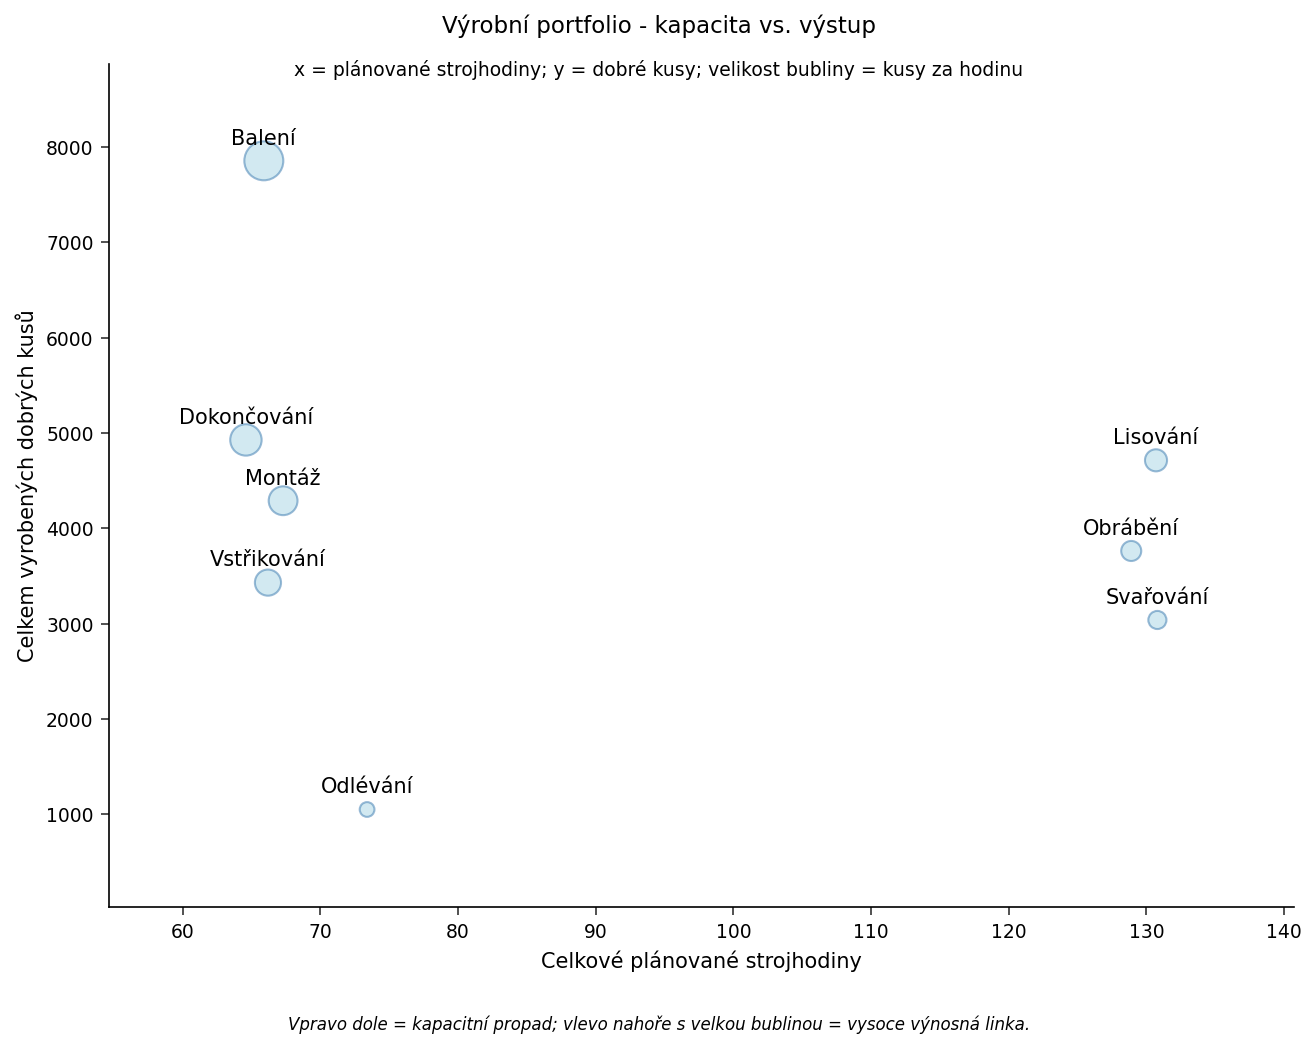

In [4]:
NÁZEV 'Výrobní portfolio - kapacita vs. výstup';
title2 'x = plánované strojhodiny; y = dobré kusy; velikost bubliny = kusy za hodinu';
footnote JUSTIFY=LEFT
    'Vpravo dole = kapacitní propad; vlevo nahoře s velkou bublinou = vysoce výnosná linka.';

PROCEDURA SGPLOT data=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ŠTÍTEK='Celkové plánované strojhodiny';
    YAXIS ŠTÍTEK='Celkem vyrobených dobrých kusů';
SPUSTIT;

NÁZEV; title2; footnote;

## 5. Výstup podle linky, rozložený podle závodu

Abychom viděli, jak se výstup každé linky rozděluje mezi tři závody, graf `VBAR product_line / response=good_units group=plant` skládá příspěvky závodů uvnitř každého sloupce. Toto je segmentační pohled: ukazuje jak celkovou výšku (dobré kusy na linku), tak mix závodů uvnitř každého sloupce, takže lze odhalit linky, kde jeden závod dominuje výstupu.

                                Dobré kusy podle produktové linky, členěno podle závodu                                 
                              Výška sloupce = celkem dobrých kusů; segmenty = podíl závodu                              




NOTE: Option TITLE changed to Dobré kusy podle produktové linky, členěno podle závodu.
NOTE: Option TITLE2 changed to Výška sloupce = celkem dobrých kusů; segmenty = podíl závodu.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


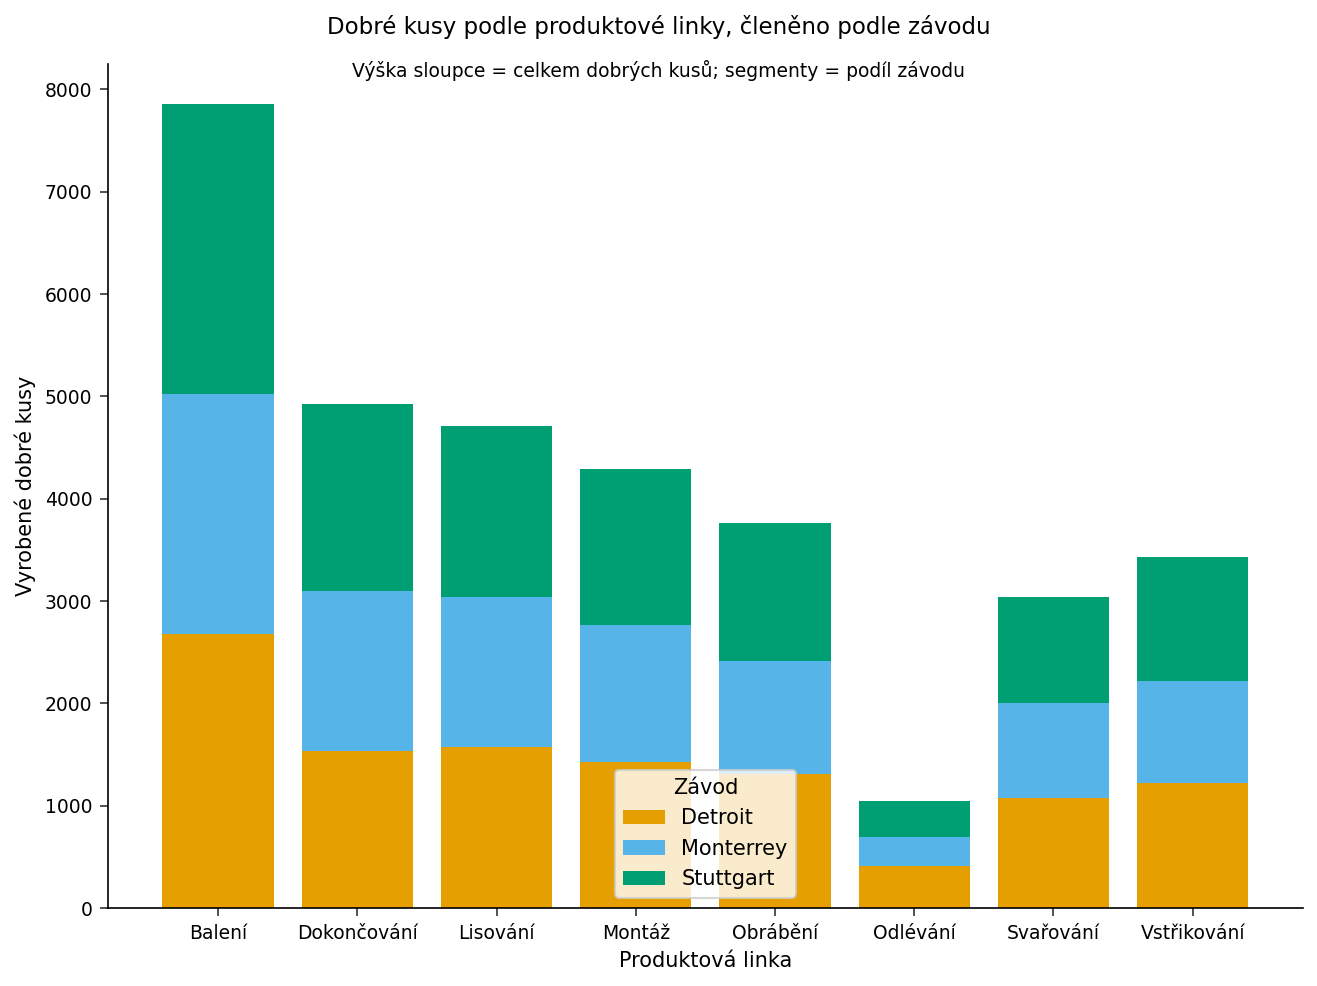

In [5]:
NÁZEV 'Dobré kusy podle produktové linky, členěno podle závodu';
title2 'Výška sloupce = celkem dobrých kusů; segmenty = podíl závodu';

PROCEDURA SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ŠTÍTEK='Produktová linka' fitpolicy=ROTATE;
    YAXIS ŠTÍTEK='Vyrobené dobré kusy';
    keylegend / NÁZEV='Závod' position=bottom;
SPUSTIT;

NÁZEV; title2;

## 6. Detail produktivity jednoho závodu (WHERE)

Vodorovné sloupce (`HBAR`) se hodí pro dlouhé popisky produktových linek. Klauzule `WHERE` omezuje výběr na závod Stuttgart a sloupce jsou vykresleny pro `units_per_hr`, takže graf řadí linky Stuttgartu podle produktivity. Protože vstup je seřazen vzestupně podle míry, nejméně produktivní linka je dole a nejproduktivnější nahoře.

                                  Závod Stuttgart - linky seřazené podle produktivity                                   


Délka sloupce = dobré kusy na strojhodinu (detail jednoho závodu).



NOTE: Option TITLE changed to Závod Stuttgart - linky seřazené podle produktivity.
NOTE: Option FOOTNOTE changed to Délka sloupce = dobré kusy na strojhodinu (detail jednoho závodu)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


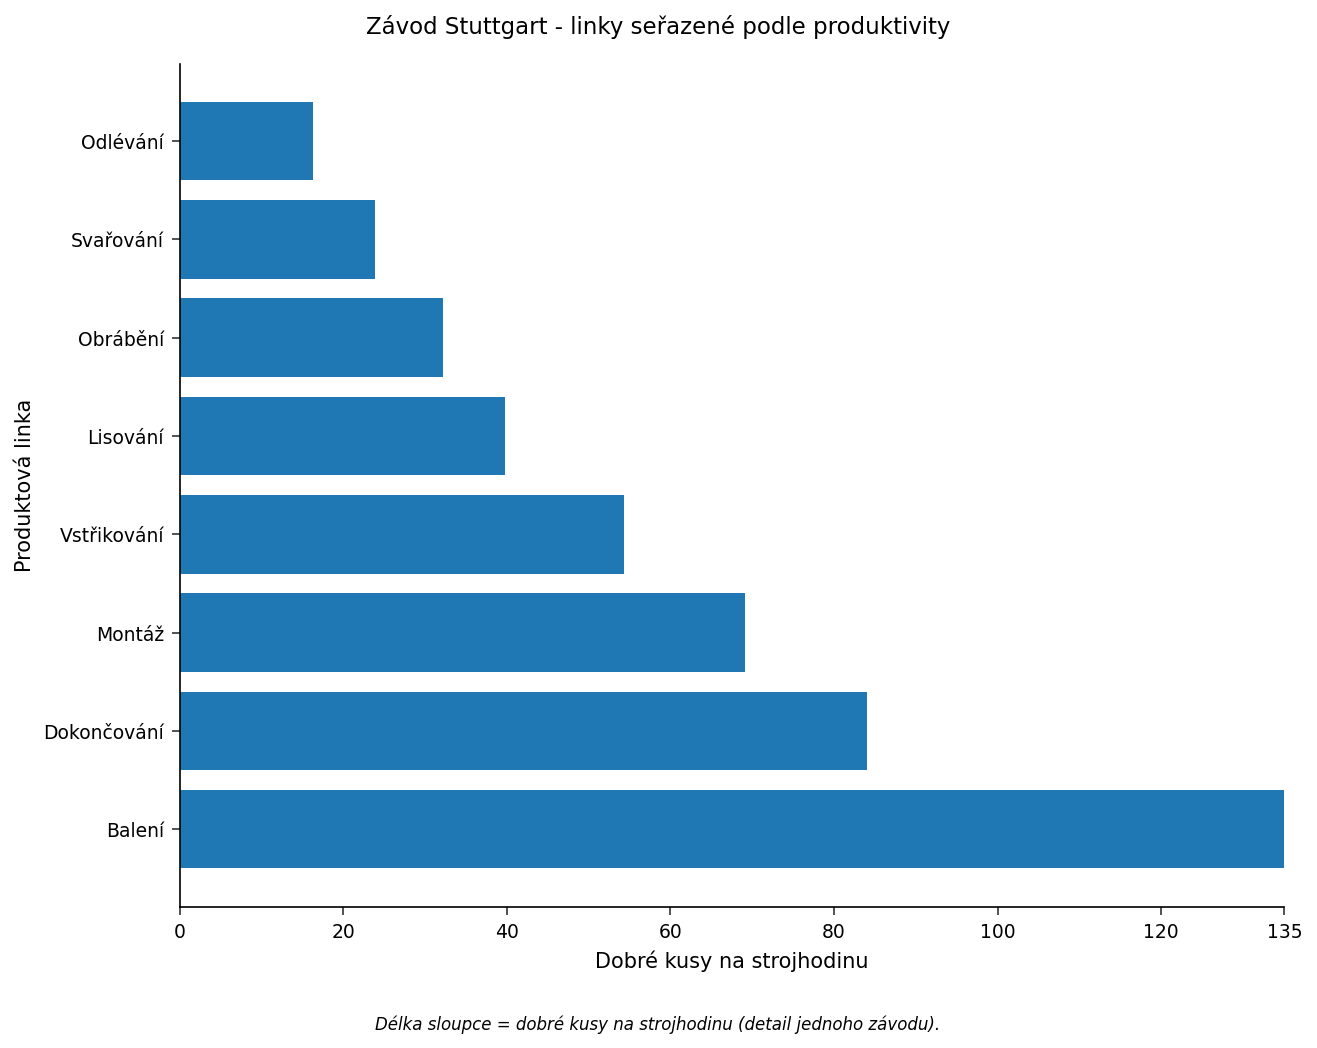

In [6]:
NÁZEV 'Závod Stuttgart - linky seřazené podle produktivity';
footnote JUSTIFY=LEFT 'Délka sloupce = dobré kusy na strojhodinu (detail jednoho závodu).';

PROCEDURA SGPLOT data=work.line_capacity;
    KDE plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ŠTÍTEK='Dobré kusy na strojhodinu';
    YAXIS ŠTÍTEK='Produktová linka';
SPUSTIT;

NÁZEV; footnote;

## 7. Srovnání závodů vedle sebe (seskupené sloupce)

Pro porovnání tří závodů linku po lince kreslí seskupený sloupcový graf (`GROUPDISPLAY=CLUSTER`) Detroit, Monterrey a Stuttgart jako sousední sloupce v rámci každé produktové linky. Toto je pohled typu jablka s jablky: pro každou linku lze vyčíst, který závod vyrobil nejvíce dobrých kusů, díky čemuž jsou rozdíly v efektivitě závodů (Stuttgart nejvyšší, Monterrey nejnižší) přímo viditelné.

                                      Dobré kusy podle linky a závodu - vedle sebe                                      
                        Seskupené sloupce: jeden sloupec na závod v rámci každé produktové linky                        




NOTE: Option TITLE changed to Dobré kusy podle linky a závodu - vedle sebe.
NOTE: Option TITLE2 changed to Seskupené sloupce: jeden sloupec na závod v rámci každé produktové linky.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


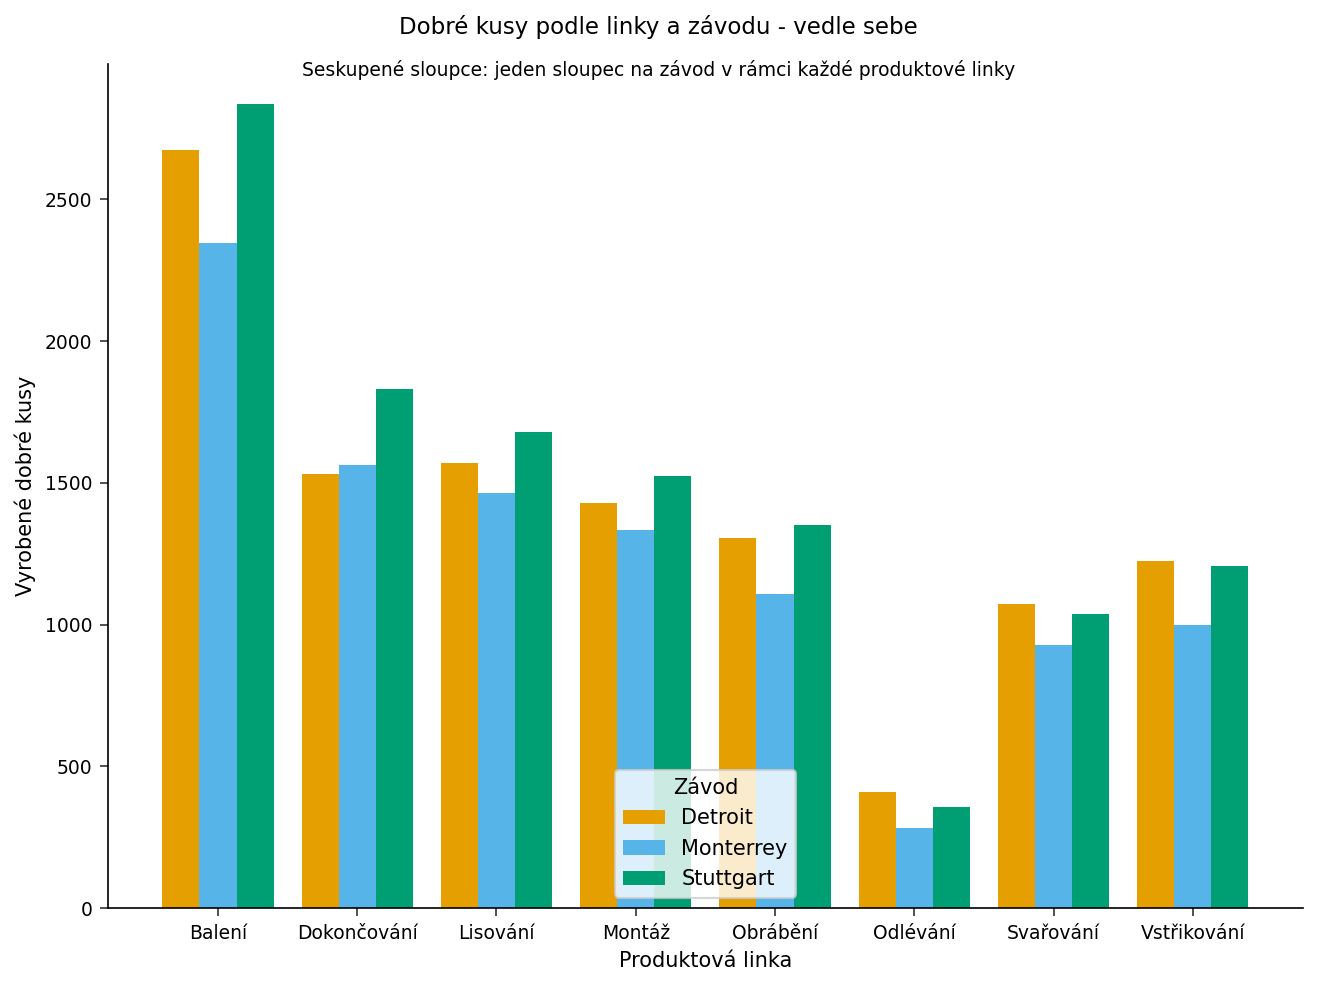

In [7]:
NÁZEV 'Dobré kusy podle linky a závodu - vedle sebe';
title2 'Seskupené sloupce: jeden sloupec na závod v rámci každé produktové linky';

PROCEDURA SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ŠTÍTEK='Produktová linka' fitpolicy=ROTATE;
    YAXIS ŠTÍTEK='Vyrobené dobré kusy';
    keylegend / NÁZEV='Závod' position=bottom;
SPUSTIT;

NÁZEV; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interpretace

Vynesení kapacity a výstupu na stejné osy odhaluje vztah, který by jednorozměrný sloupcový graf skryl. **Odlévání** je nejvýraznějším kapacitním propadem portfolia: v žebříčku produktivity je na posledním místě s **14,3 dobrými kusy na strojhodinu** a v bublinovém grafu padá do levého dolního rohu jako malá bublina — spotřebuje **10,1 %** celkových plánovaných hodin, ale vrací pouze **3,2 %** dobrých kusů (nese také nejnižší výtěžnost, ~91 %, kvůli vysoké míře zmetkovitosti). Je hlavním kandidátem na kaizen zaměřený na zkrácení cyklu a snížení zmetkovitosti. Na opačném konci je **Balení** špičkovou vysoce výnosnou linkou s **119,2 kusy na strojhodinu** — velká bublina vysoko na ose výstupu, která mění **9,1 %** kapacity na **23,8 %** všech dobrých kusů; ochrana její dostupnosti přináší neúměrně velký výstup. **Dokončování** (76,3 kusů/hod) a **Montáž** (63,7) následují stejný vysoce výnosný vzor.

Vzor je systematický: čtyři pomalé, na kapacitu náročné linky na začátku procesu — Odlévání, Svařování (23,2 kusů/hod), Obrábění (29,2) a Lisování (36,1) — společně spotřebují zhruba **64 %** plánovaných hodin, ale dodají jen asi **38 %** dobrých kusů, zatímco čtyři rychlé linky na konci procesu přebíjí očekávání vzhledem k hodinám, které čerpají. Pohled seskupený podle závodu a vedle sebe postavené seskupené sloupce ukazují dimenzi závodu za tímto jevem: **Stuttgart** běží nejžhavěji s **49,9 dobrými kusy na strojhodinu**, **Detroit** je uprostřed s **44,9** a **Monterrey** zaostává s **41,6** — což odpovídá vyššímu modelovanému prostoji Monterrey. Provozně to ukazuje na přerozdělení plánovaných hodin směrem k vysoce výnosným linkám na konci procesu a benchmarking prostojů Monterrey oproti praxi Stuttgartu.

*Pouze syntetická data — čísla ilustrují dvourozměrnou vizualizaci kapacity vs. výstupu pomocí PROC SGPLOT, nikoli skutečnou výkonnost závodu.*